# Train Soccer Ball Detector on Kaggle

Notebook này là bản đã chỉnh từ `train_ball_detector.ipynb` để chạy trực tiếp trên **Kaggle Notebook**.

## Trước khi chạy trên Kaggle
1. Vào **Settings** của notebook.
2. Bật **Accelerator = GPU**.
3. Bật **Internet = On**.
4. Vào **Add-ons → Secrets** và tạo secret:
   - Name: `ROBOFLOW_API_KEY`
   - Value: API key Roboflow của bạn.

Output chính sau khi train sẽ được copy ra:

```text
/kaggle/working/exported_models/football-ball-detection.pt
```

## 1. Kiểm tra GPU

In [1]:
!nvidia-smi || echo "Không thấy GPU. Hãy bật Accelerator = GPU trong Kaggle Settings."

Wed May 20 18:39:49 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 2. Thiết lập môi trường Kaggle

In [2]:
import os
from pathlib import Path

HOME = "/kaggle/working"
DATASETS_DIR = f"{HOME}/datasets"
EXPORT_DIR = f"{HOME}/exported_models"

os.makedirs(DATASETS_DIR, exist_ok=True)
os.makedirs(EXPORT_DIR, exist_ok=True)

# Tắt WandB để YOLO không hỏi login trong lúc train.
os.environ["WANDB_DISABLED"] = "true"
os.environ["YOLO_CONFIG_DIR"] = f"{HOME}/.config/Ultralytics"

print("HOME:", HOME)
print("DATASETS_DIR:", DATASETS_DIR)
print("EXPORT_DIR:", EXPORT_DIR)

HOME: /kaggle/working
DATASETS_DIR: /kaggle/working/datasets
EXPORT_DIR: /kaggle/working/exported_models


## 3. Cài dependency

In [3]:
!pip install -q --upgrade ultralytics roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 62.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 83.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.25.1 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2026.2.0 which is incompatible.


## 4. Import thư viện và lấy Roboflow API key từ Kaggle Secrets

In [4]:
import os
import shutil
import yaml
from pathlib import Path
from IPython.display import Image, display

from roboflow import Roboflow

try:
    from kaggle_secrets import UserSecretsClient
    ROBOFLOW_API_KEY = UserSecretsClient().get_secret("ROBOFLOW_API_KEY")
except Exception as e:
    ROBOFLOW_API_KEY = os.environ.get("ROBOFLOW_API_KEY")

if not ROBOFLOW_API_KEY:
    raise RuntimeError(
        "Thiếu ROBOFLOW_API_KEY. Trên Kaggle hãy vào Add-ons → Secrets "
        "và thêm secret tên ROBOFLOW_API_KEY."
    )

print("Đã đọc Roboflow API key.")

Đã đọc Roboflow API key.


## 5. Tải dataset từ Roboflow

In [5]:
%cd {DATASETS_DIR}

rf = Roboflow(api_key=ROBOFLOW_API_KEY)
project = rf.workspace("roboflow-jvuqo").project("football-ball-detection-rejhg")
version = project.version(2)
dataset = version.download("yolov8")

print("Dataset location:", dataset.location)

/kaggle/working/datasets
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to football-ball-detection-2 in yolov8:: 100%|██████████| 4434/4434 [00:01<00:00, 3867.58it/s]


WARNING ⚠️ user config directory '/kaggle/working/.config/Ultralytics/Ultralytics' is not writable, using '/tmp/Ultralytics'. Set YOLO_CONFIG_DIR to override.
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/tmp/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Dataset location: /kaggle/working/datasets/football-ball-detection-2


## 6. Sửa `data.yaml` cho đúng format đường dẫn của Ultralytics

In [6]:
data_yaml = Path(dataset.location) / "data.yaml"

with open(data_yaml, "r") as f:
    data = yaml.safe_load(f)

# Roboflow thường tạo thư mục train/valid/test cùng cấp với data.yaml.
# Các đường dẫn tương đối dưới đây phù hợp với Ultralytics khi chạy trên Kaggle.
data["train"] = "../train/images"
data["val"] = "../valid/images"

test_images = Path(dataset.location).parent / "test" / "images"
if test_images.exists():
    data["test"] = "../test/images"

with open(data_yaml, "w") as f:
    yaml.safe_dump(data, f, sort_keys=False)

print(data_yaml)
print(data)

/kaggle/working/datasets/football-ball-detection-2/data.yaml
{'names': ['ball'], 'nc': 1, 'roboflow': {'license': 'CC BY 4.0', 'project': 'football-ball-detection-rejhg', 'url': 'https://universe.roboflow.com/roboflow-jvuqo/football-ball-detection-rejhg/dataset/2', 'version': 2, 'workspace': 'roboflow-jvuqo'}, 'test': '../test/images', 'train': '../train/images', 'val': '../valid/images'}


## 7. Train model

In [7]:
%cd {HOME}

TASK = "detect"
MODEL = "yolov8x.pt"
EPOCHS = 50
IMGSZ = 1280
BATCH = -1
DEVICE = 0
RUN_NAME = "football_ball_detector_kaggle"
RUN_DIR = f"{HOME}/runs/detect/{RUN_NAME}"

# Original notebook dùng batch=12. Trên Kaggle nên để -1 để YOLO tự chọn batch phù hợp GPU.
print("Training config:")
print("TASK:", TASK)
print("MODEL:", MODEL)
print("EPOCHS:", EPOCHS)
print("IMGSZ:", IMGSZ)
print("BATCH:", BATCH)
print("RUN_DIR:", RUN_DIR)

/kaggle/working
Training config:
TASK: detect
MODEL: yolov8x.pt
EPOCHS: 50
IMGSZ: 1280
BATCH: -1
RUN_DIR: /kaggle/working/runs/detect/football_ball_detector_kaggle


In [8]:
!yolo task={TASK} mode=train \
    model={MODEL} \
    data={dataset.location}/data.yaml \
    batch={BATCH} \
    epochs={EPOCHS} \
    imgsz={IMGSZ} \
    device={DEVICE} \
    project={HOME}/runs/detect \
    name={RUN_NAME} \
    exist_ok=True \
    plots=True

Ultralytics 8.4.52 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/datasets/football-ball-detection-2/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1280, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8x.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=football_ball_detector_kaggle, nbs=64, nms=False, opset=None, optimize=Fal

## 8. Xem nhanh kết quả train

RUN_DIR: /kaggle/working/runs/detect/football_ball_detector_kaggle
total 3.1M
drwxr-xr-x 3 root root 4.0K May 21 04:17 .
drwxr-xr-x 3 root root 4.0K May 20 18:40 ..
-rw-r--r-- 1 root root 1.7K May 20 18:40 args.yaml
-rw-r--r-- 1 root root 104K May 21 04:17 BoxF1_curve.png
-rw-r--r-- 1 root root  85K May 21 04:17 BoxP_curve.png
-rw-r--r-- 1 root root  78K May 21 04:17 BoxPR_curve.png
-rw-r--r-- 1 root root 103K May 21 04:17 BoxR_curve.png
-rw-r--r-- 1 root root  91K May 21 04:17 confusion_matrix_normalized.png
-rw-r--r-- 1 root root  85K May 21 04:17 confusion_matrix.png
-rw-r--r-- 1 root root 110K May 20 18:40 labels.jpg
-rw-r--r-- 1 root root 6.1K May 21 04:16 results.csv
-rw-r--r-- 1 root root 303K May 21 04:17 results.png
-rw-r--r-- 1 root root 218K May 20 18:40 train_batch0.jpg
-rw-r--r-- 1 root root 203K May 20 18:41 train_batch1.jpg
-rw-r--r-- 1 root root 170K May 20 18:41 train_batch2.jpg
-rw-r--r-- 1 root root 171K May 21 02:22 train_batch78640.jpg
-rw-r--r-- 1 root root 171K M

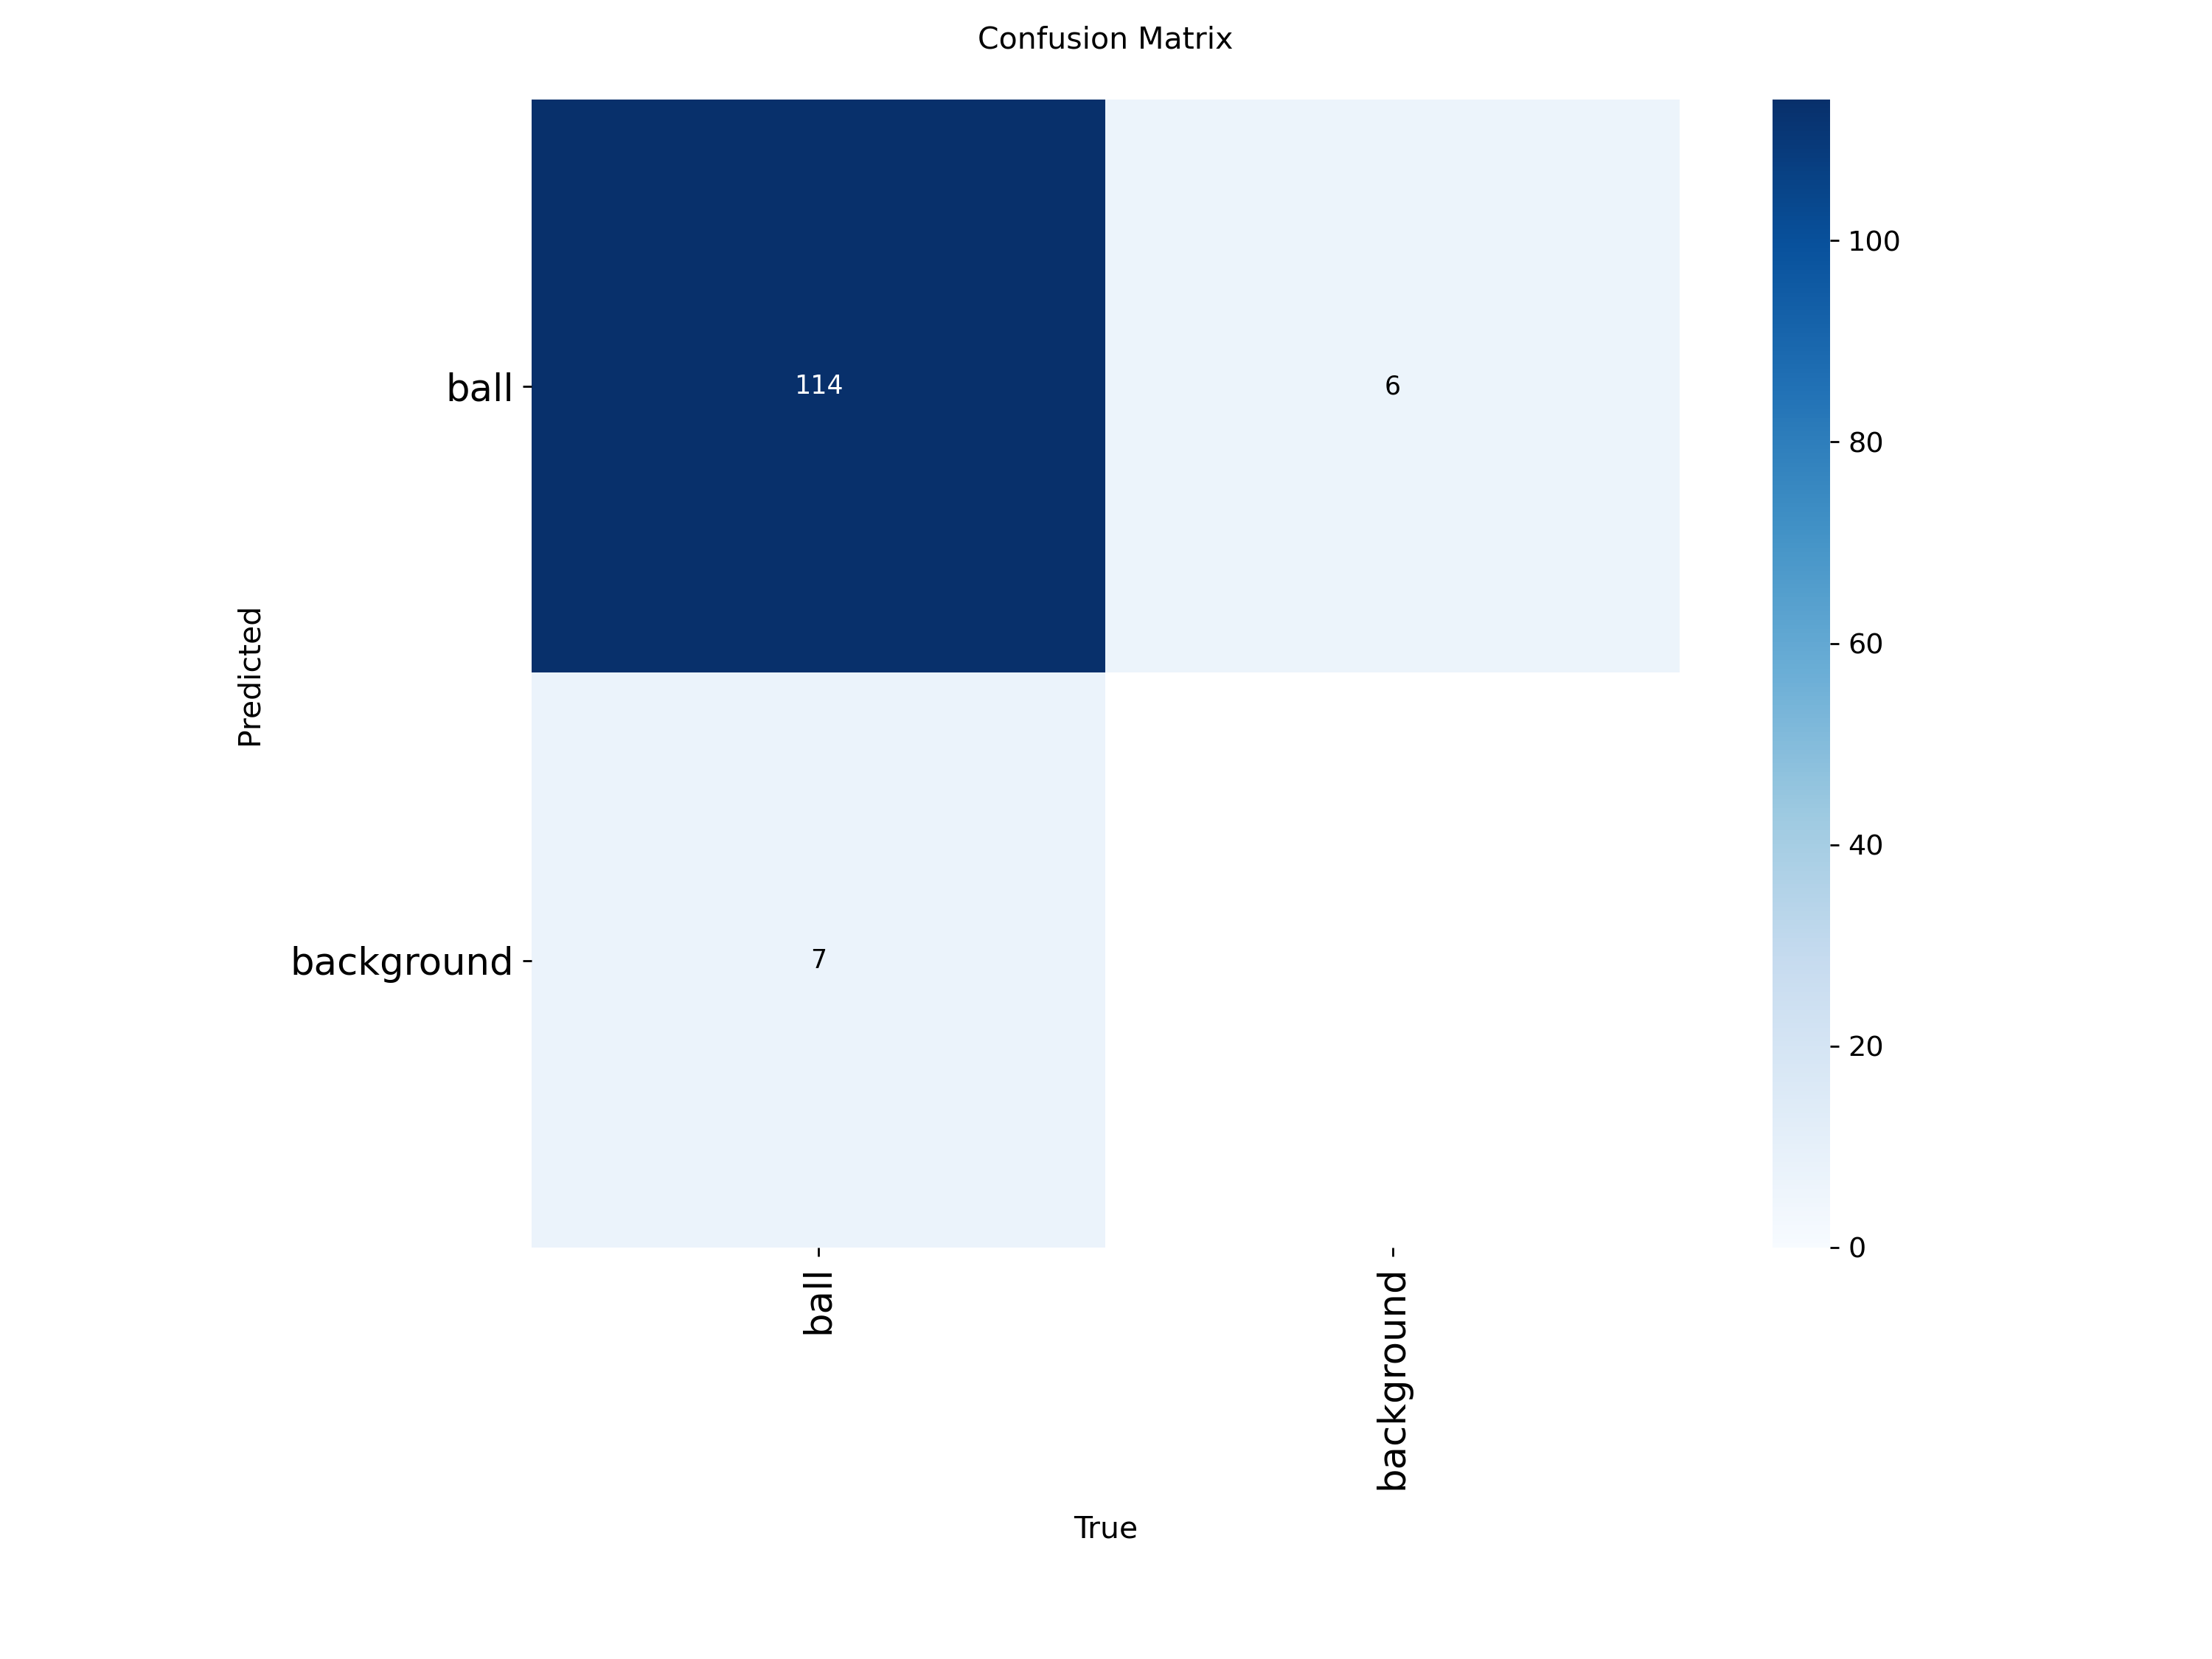


Preview: /kaggle/working/runs/detect/football_ball_detector_kaggle/results.png


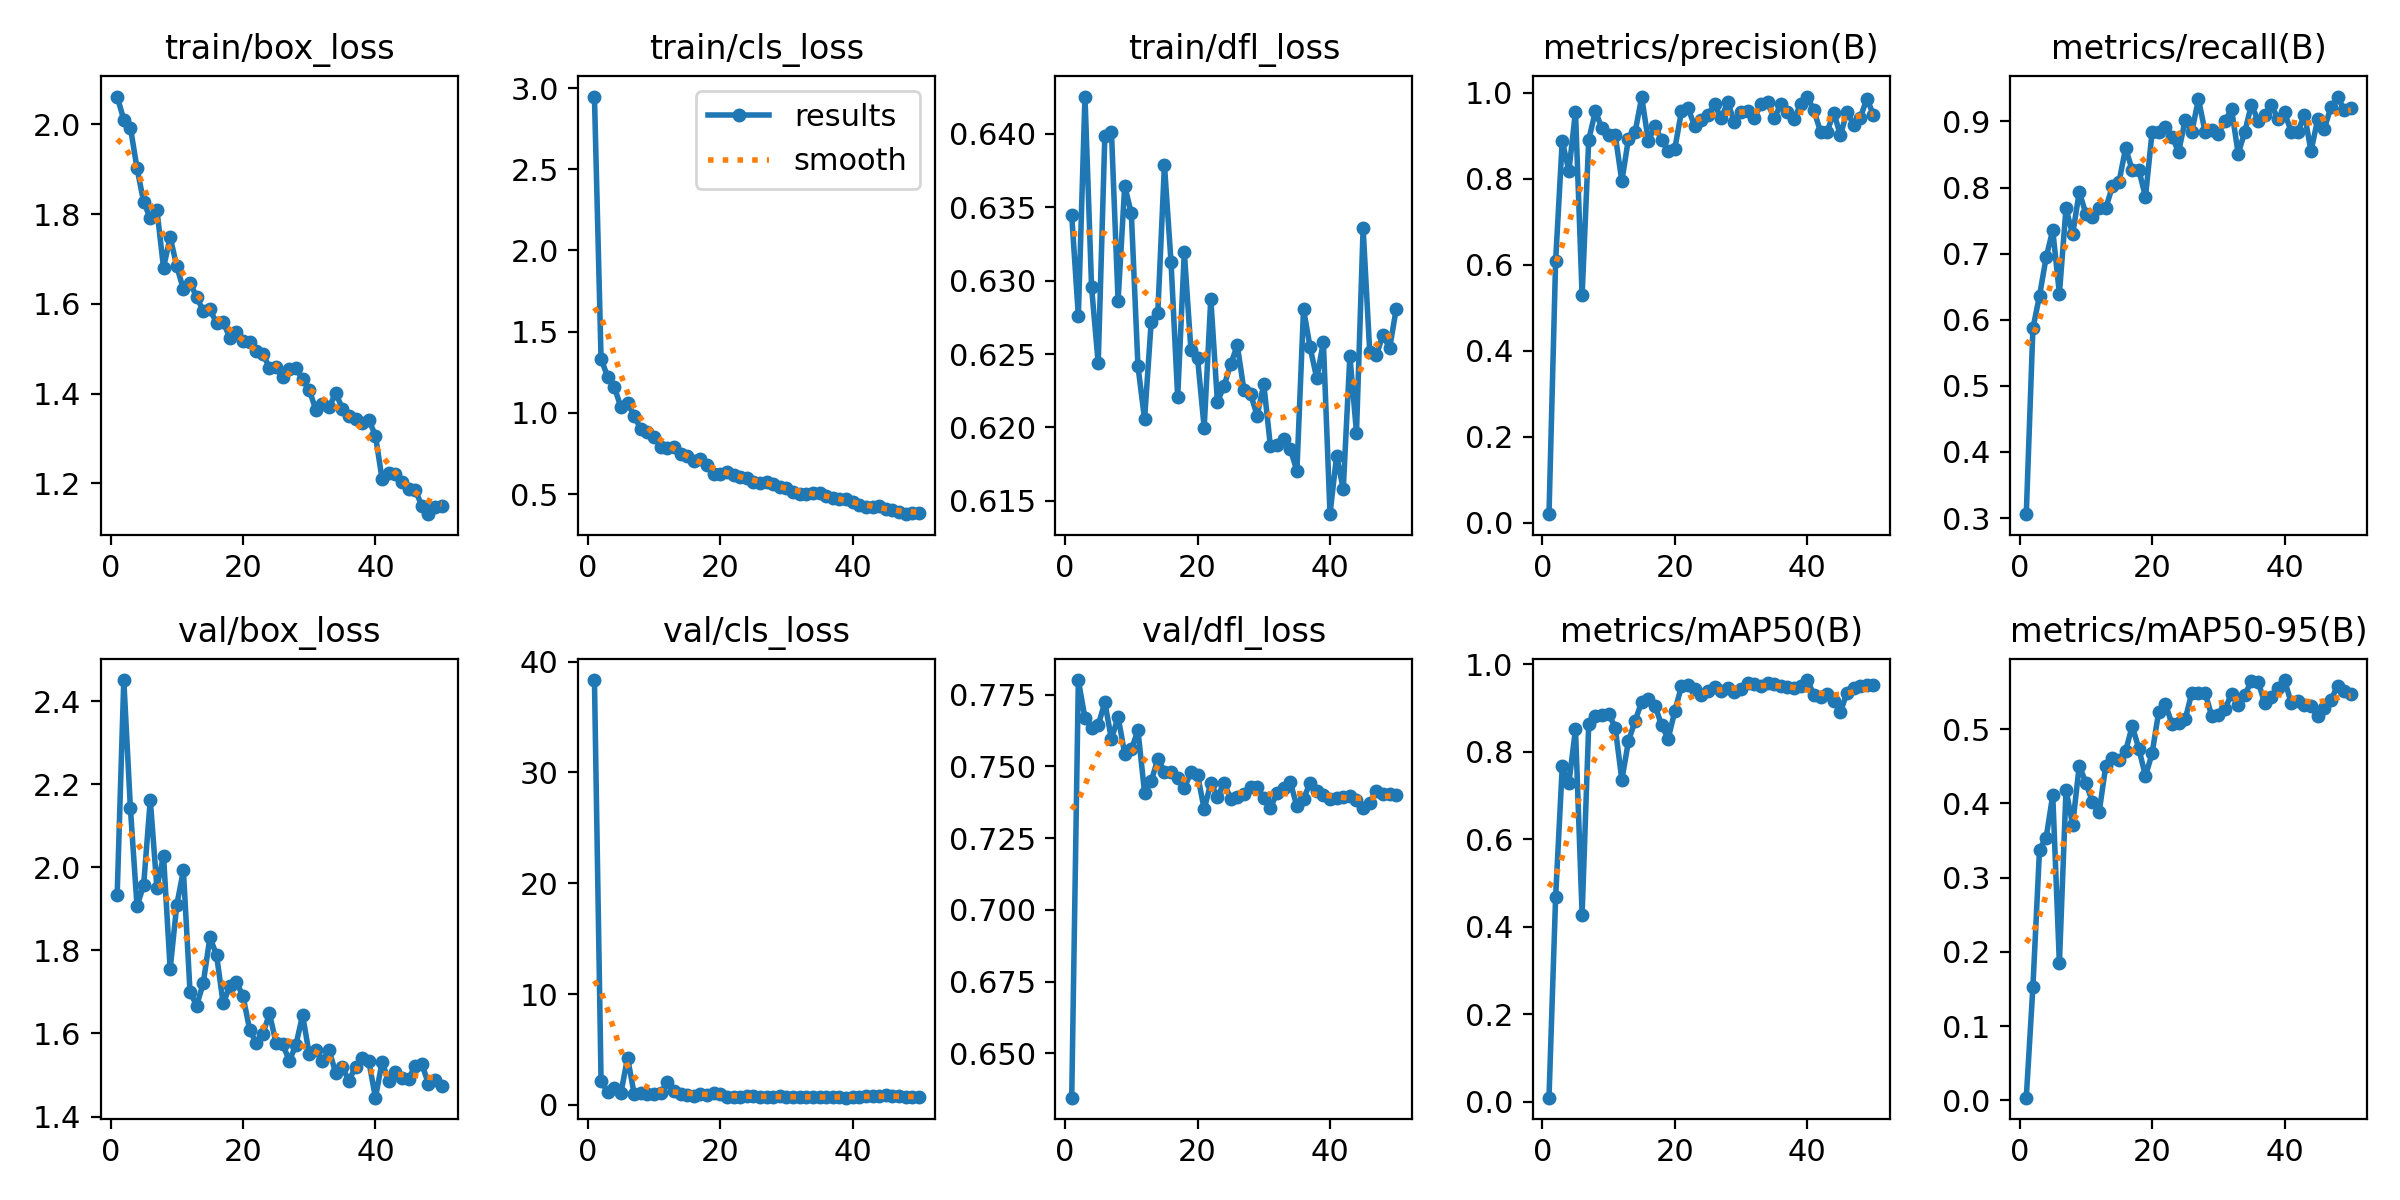


Preview: /kaggle/working/runs/detect/football_ball_detector_kaggle/val_batch0_pred.jpg


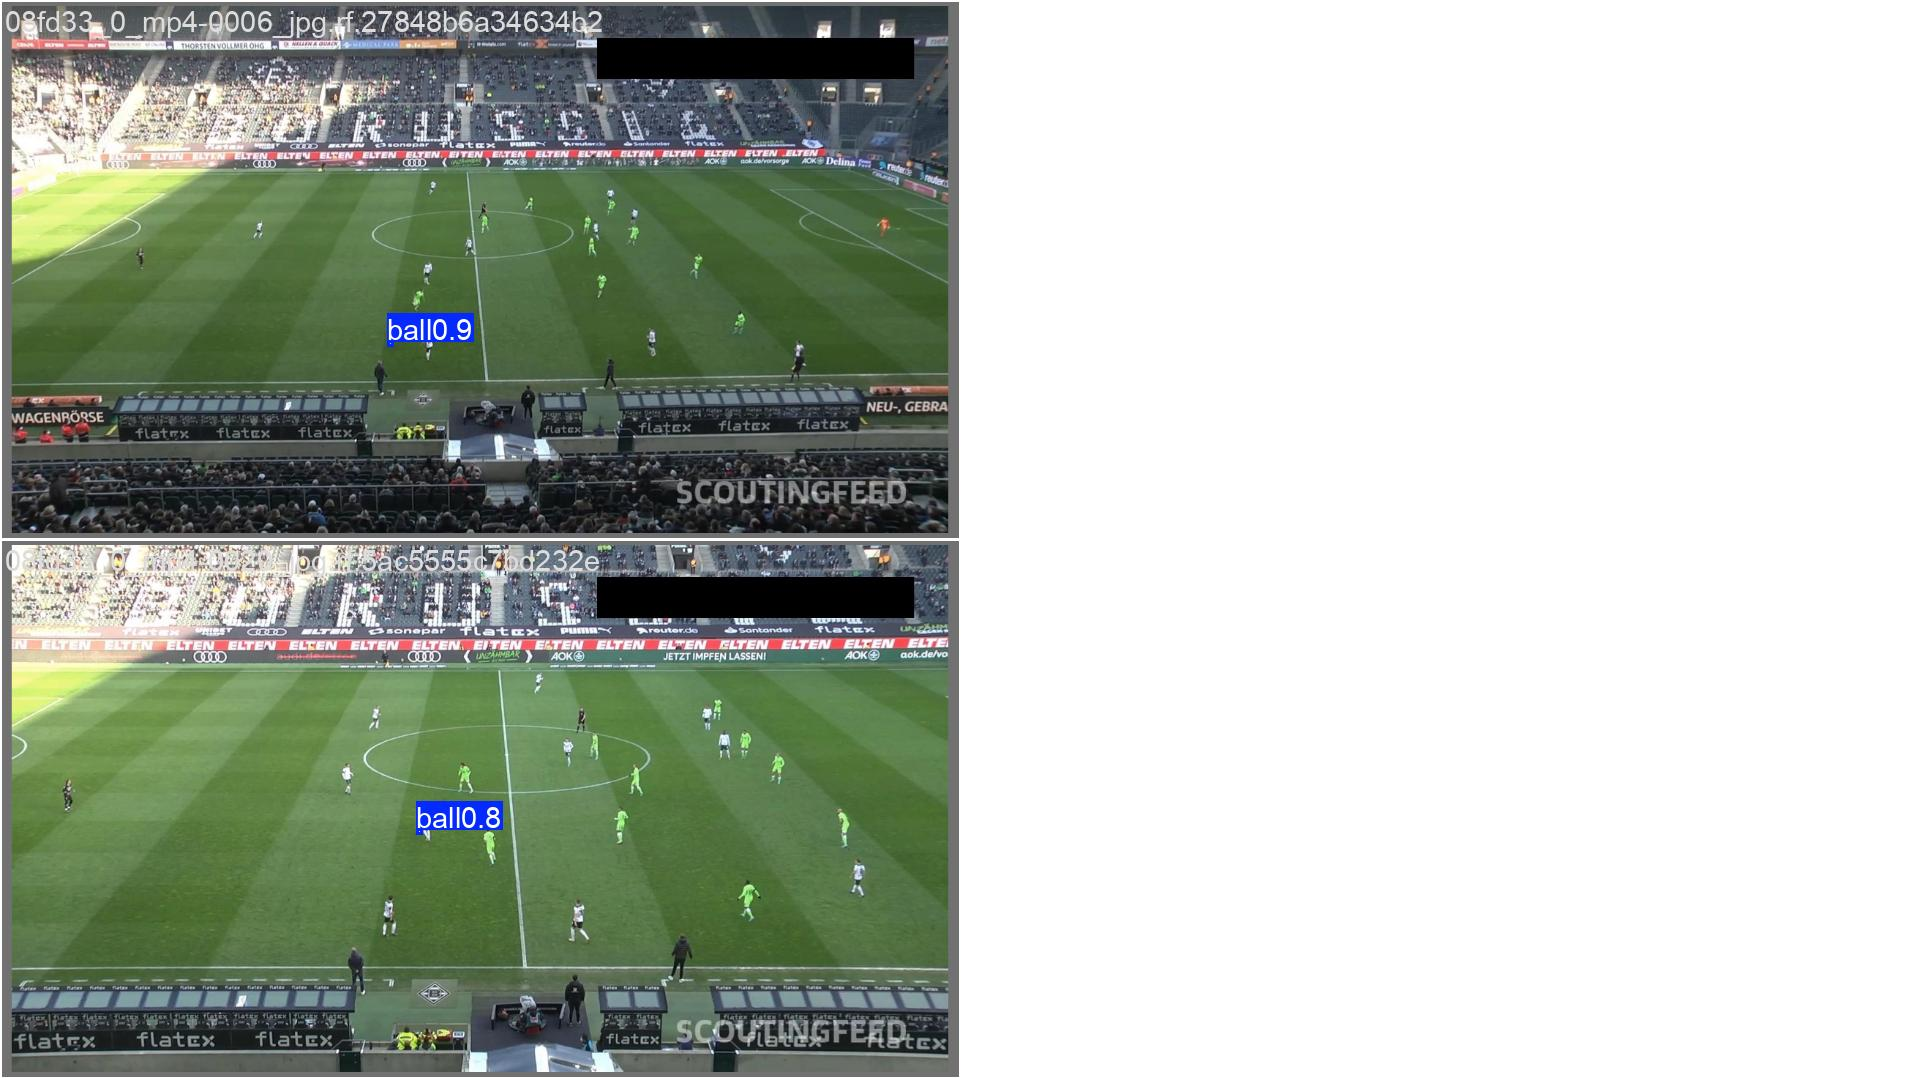

In [9]:
RUN_DIR = Path(f"{HOME}/runs/detect/{RUN_NAME}")
print("RUN_DIR:", RUN_DIR)
!ls -lah {RUN_DIR}

for img_name in ['confusion_matrix.png', 'results.png', 'val_batch0_pred.jpg']:
    img_path = RUN_DIR / img_name
    if img_path.exists():
        print("\nPreview:", img_path)
        display(Image(filename=str(img_path), width=700))
    else:
        print("Không tìm thấy:", img_path)

## 9. Validate model tốt nhất

In [10]:
BEST_PT = Path(RUN_DIR) / "weights" / "best.pt"
print("BEST_PT:", BEST_PT)

!yolo task={TASK} mode=val \
    model={BEST_PT} \
    data={dataset.location}/data.yaml \
    imgsz={IMGSZ} \
    device={DEVICE}

BEST_PT: /kaggle/working/runs/detect/football_ball_detector_kaggle/weights/best.pt
Ultralytics 8.4.52 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 113 layers, 68,124,531 parameters, 0 gradients, 257.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3585.1±958.6 MB/s, size: 208.9 KB)
val: Scanning /kaggle/working/datasets/football-ball-detection-2/valid/labels.cache... 121 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 121/121 23.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 2.9s/it 23.0s
                   all        121        121      0.991      0.914      0.963      0.606
Speed: 6.9ms preprocess, 175.6ms inference, 0.0ms loss, 0.6ms postprocess per image
Results saved to /kaggle/working/runs/detect/val
💡 Learn more at https://docs.ultralytics.com/modes/val


## 10. Copy model ra thư mục export để tải về

In [11]:
EXPORT_PATH = Path(EXPORT_DIR) / "football-ball-detection.pt"
shutil.copy2(BEST_PT, EXPORT_PATH)

print("Đã copy model sang:")
print(EXPORT_PATH)
print("Dung lượng MB:", round(EXPORT_PATH.stat().st_size / (1024 * 1024), 2))

Đã copy model sang:
/kaggle/working/exported_models/football-ball-detection.pt
Dung lượng MB: 130.44


## 11. Nén toàn bộ kết quả train để tải về từ Kaggle Output

In [12]:
ZIP_PATH = f"{HOME}/train_ball_detector_kaggle_outputs.zip"

!cd {HOME} && zip -qr train_ball_detector_kaggle_outputs.zip runs/detect/football_ball_detector_kaggle exported_models/football-ball-detection.pt

print("ZIP output:", ZIP_PATH)

ZIP output: /kaggle/working/train_ball_detector_kaggle_outputs.zip


## 12. Deploy lên Roboflow — tùy chọn

In [13]:
# Chỉ chạy cell này nếu bạn muốn upload/deploy model trở lại Roboflow.
# Nếu chỉ cần lấy file .pt cho project, có thể bỏ qua.

# project.version(dataset.version).deploy(
#     model_type="yolov8",
#     model_path=str(RUN_DIR)
# )